#Bibliotecas:

In [1]:
import osmnx as ox
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

#Escolha do local do Grafo

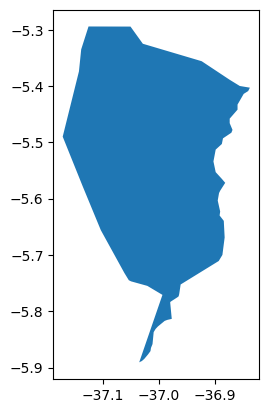

In [2]:
place = "Assu, Brazil"

edge = ox.geocode_to_gdf(place)

edge.plot()
plt.savefig("municipio_borda.png", dpi=300, bbox_inches='tight')

Arestas em G_undirected: 4319


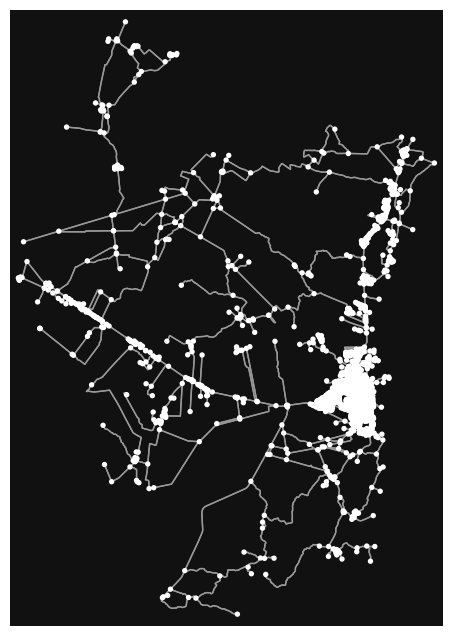

In [3]:
G = ox.graph_from_place(place, network_type="drive")

fig, ax = ox.plot_graph(G, show=False, save=True, filepath="grafo.png", dpi=300)

# 2. Conversão para não direcionado
G_undirected = ox.convert.to_undirected(G)

print(f"Arestas em G_undirected: {G_undirected.number_of_edges()}")

#Análise Estrutural e Hubs

In [4]:
# 1. Grau Absoluto (Contagem de ruas por cruzamento)
degree = dict(G_undirected.degree())

# 2. Degree Centrality (Métrica normalizada)
degree_centrality = nx.degree_centrality(G_undirected)

# 3. Closeness Centrality
closeness_centrality = nx.closeness_centrality(G_undirected)

# 4. Betweenness Centrality
betweenness_centrality = nx.betweenness_centrality(G_undirected, normalized=True)

# 5. Eigenvector Centrality
G_simples = nx.Graph(G_undirected)
eigenvector_centrality = nx.eigenvector_centrality(G_simples, max_iter=1000)

df_metricas = pd.DataFrame({
    'Degree': degree,
    'Degree_Centrality': degree_centrality,
    'Closeness': closeness_centrality,
    'Betweenness': betweenness_centrality,
    'Eigenvector': eigenvector_centrality
})

# Mostra os 5 nós com maior Betweenness (os maiores gargalos da cidade)
df_metricas.sort_values(by='Betweenness', ascending=False).head(5)

,Degree,Degree_Centrality,Closeness,Betweenness,Eigenvector
6258979020,3,0.001017,0.028252,0.250245,4.606332e-09
2085821372,3,0.001017,0.028822,0.249809,3.320318e-08
7050682147,3,0.001017,0.028533,0.249790,1.215790e-08
7053390191,3,0.001017,0.030714,0.249683,2.136319e-06
6258979017,3,0.001017,0.027977,0.243845,1.739196e-09


In [8]:
# Função melhorada para descobrir nomes, referências ou tipos das ruas
def obter_ruas_do_no_melhorado(node_id, grafo):
    ruas = set() 
    
    for u, v, data in grafo.edges(node_id, data=True):
        nome = data.get('name')
        ref = data.get('ref')         # Busca referência (ex: BR-304)
        tipo = data.get('highway')    # Busca o tipo de via (ex: primary, track)
        
        identificador = None
        
        # 1. Tenta pegar o nome
        if nome:
            identificador = nome if isinstance(nome, str) else nome[0]
        # 2. Se não tiver nome, tenta pegar a referência
        elif ref:
            identificador = f"Rodovia {ref if isinstance(ref, str) else ref[0]}"
        # 3. Se não tiver nenhum dos dois, pega o tipo de estrada
        elif tipo:
            tipo_str = tipo if isinstance(tipo, str) else tipo[0]
            identificador = f"Via tipo '{tipo_str}'"
            
        if identificador:
            ruas.add(identificador)
            
    if ruas:
        return " Cruzamento: " + " / ".join(ruas)
    else:
        return "Via não classificada no OSM"

# Aplica a nova função
df_metricas['Cruzamento'] = [obter_ruas_do_no_melhorado(n, G_undirected) for n in df_metricas.index]

# Remove o limite de caracteres por coluna
pd.set_option('display.max_colwidth', None)

# Mostra o DataFrame novamente
cols = ['Cruzamento', 'Betweenness', 'Degree'] 
df_metricas.sort_values(by='Betweenness', ascending=False)[cols].head(5)

,Cruzamento,Betweenness,Degree
6258979020,Cruzamento: Via tipo 'unclassified' / Rodovia BR-304,0.250245,3
2085821372,Cruzamento: Via tipo 'trunk_link' / Rodovia BR-304,0.249809,3
7050682147,Cruzamento: Via tipo 'unclassified' / Rodovia BR-304,0.249790,3
7053390191,Cruzamento: Via tipo 'residential' / Rodovia BR-304,0.249683,3
6258979017,Cruzamento: Via tipo 'unclassified',0.243845,3


Imagem salva com sucesso como 'grafo_gargalos_assu.png'!


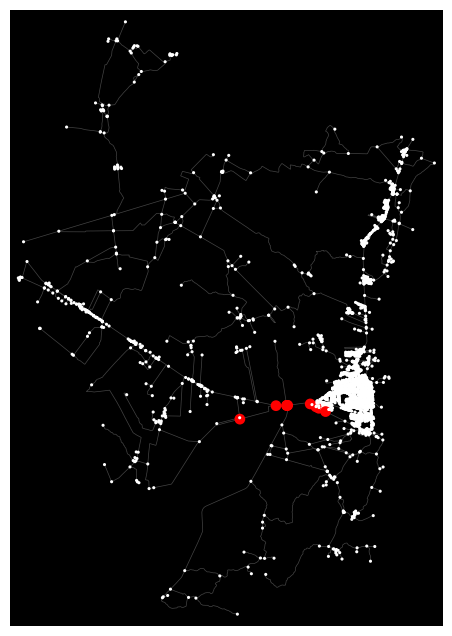

In [9]:
# 1. Pegamos os IDs dos 10 nós com maior Betweenness Centrality
top_10_gargalos = df_metricas.sort_values(by='Betweenness', ascending=False).head(10).index.tolist()

# 2. Criamos as listas vazias para armazenar as cores e tamanhos
cores_dos_nos = []
tamanhos_dos_nos = []

# 3. Percorremos todos os nós do grafo original na ordem exata
for no in G_undirected.nodes():
    if no in top_10_gargalos:
        cores_dos_nos.append('red')   # Destaca em vermelho
        tamanhos_dos_nos.append(60)   # Deixa o nó bem grande
    else:
        cores_dos_nos.append('white') # Cor padrão
        tamanhos_dos_nos.append(5)    # Tamanho padrão pequeno

# 4. Salvamos a imagem direto no arquivo .png (sem plotar na tela)
fig, ax = ox.plot_graph(
    G_undirected,
    node_color=cores_dos_nos,
    node_size=tamanhos_dos_nos,
    edge_color="#444444",
    edge_linewidth=0.5,
    bgcolor="black",
    show=False,                # <-- DESATIVA a exibição na tela do Notebook
    save=True,                 # <-- ATIVA o salvamento do arquivo
    filepath="grafo_gargalos_assu.png", # Define o nome e formato do arquivo
    dpi=300                    # Garante alta resolução
)

print("Imagem salva com sucesso como 'grafo_gargalos_assu.png'!")

In [15]:
# 1. Remove os self-loops (laços que conectam um nó a ele mesmo)
G_simples.remove_edges_from(nx.selfloop_edges(G_simples))

# 2. Calcula o Core Number para todos os nós (agora vai funcionar!)
core_numbers = nx.core_number(G_simples)

# 3. Adiciona o Core Number como uma nova coluna no DataFrame
df_metricas['Core_Number'] = pd.Series(core_numbers)

# 4. Descobre qual é a camada mais profunda (O K máximo da rede)
k_max = df_metricas['Core_Number'].max()
print(f"O K-Core máximo (miolo mais denso) de Assú é: {k_max}")

# 5. Extrai o subgrafo apenas com as ruas que pertencem a esse núcleo principal
k_core_max_grafo = nx.k_core(G_simples, k=k_max)

print(f"Número de cruzamentos pertencentes ao núcleo principal (K={k_max}): {k_core_max_grafo.number_of_nodes()}")

# 6. Mostra os cruzamentos que fazem parte do miolo, ordenados pelo Betweenness
cols = ['Cruzamento', 'Core_Number', 'Betweenness']
df_metricas[df_metricas['Core_Number'] == k_max].sort_values(by='Betweenness', ascending=False)[cols].head(5)

O K-Core máximo (miolo mais denso) de Assú é: 2
Número de cruzamentos pertencentes ao núcleo principal (K=2): 2563


,Cruzamento,Core_Number,Betweenness
6258979020,Cruzamento: Via tipo 'unclassified' / Rodovia BR-304,2,0.250245
2085821372,Cruzamento: Via tipo 'trunk_link' / Rodovia BR-304,2,0.249809
7050682147,Cruzamento: Via tipo 'unclassified' / Rodovia BR-304,2,0.249790
7053390191,Cruzamento: Via tipo 'residential' / Rodovia BR-304,2,0.249683
6258979017,Cruzamento: Via tipo 'unclassified',2,0.243845


In [17]:
# 1. Injetando os atributos calculados de volta nos nós do grafo
nx.set_node_attributes(G_undirected, df_metricas['Degree'].to_dict(), "degree")
nx.set_node_attributes(G_undirected, df_metricas['Betweenness'].to_dict(), "betweenness")
nx.set_node_attributes(G_undirected, df_metricas['Closeness'].to_dict(), "closeness")
nx.set_node_attributes(G_undirected, df_metricas['Core_Number'].to_dict(), "core_number")

# 2. Exportando o grafo para o formato lido pelo Gephi
ox.save_graphml(G_undirected, "assu_network.graphml")

print("Arquivo 'assu_network.graphml' exportado com sucesso!")

Arquivo 'assu_network.graphml' exportado com sucesso!


In [18]:
# Força as coordenadas a serem lidas como números (float) pelo Gephi
for no, dados in G_undirected.nodes(data=True):
    dados['Latitude'] = float(dados['y'])
    dados['Longitude'] = float(dados['x'])

# Exporta um novo arquivo corrigido
ox.save_graphml(G_undirected, "assu_network_corrigido.graphml")

print("Novo arquivo exportado com sucesso!")

Novo arquivo exportado com sucesso!


In [22]:
import networkx as nx

# 1. Converter para Grafo Simples (Isso elimina a chave "0" de vez!)
G_gephi = nx.Graph(G_undirected)

# 2. Limpar os atributos dos Nós (garantindo latitude/longitude)
for no, dados in G_gephi.nodes(data=True):
    dados['Latitude'] = float(dados['y'])
    dados['Longitude'] = float(dados['x'])
    
    for chave, valor in list(dados.items()):
        if isinstance(valor, list):
            dados[chave] = ", ".join(map(str, valor))

# 3. Limpar atributos das Arestas e remover o LineString
for u, v, dados in G_gephi.edges(data=True):
    
    # Remove a geometria complexa que o NetworkX não sabe exportar
    if 'geometry' in dados:
        del dados['geometry']
        
    for chave, valor in list(dados.items()):
        if isinstance(valor, list):
            dados[chave] = ", ".join(map(str, valor))

# 4. Exportar usando o NetworkX diretamente
nx.write_graphml(G_gephi, "assu_gephi_definitivo.graphml")

print(f"Sucesso! Grafo exportado com {G_gephi.number_of_nodes()} nós e {G_gephi.number_of_edges()} arestas!")

Sucesso! Grafo exportado com 2952 nós e 4290 arestas!
